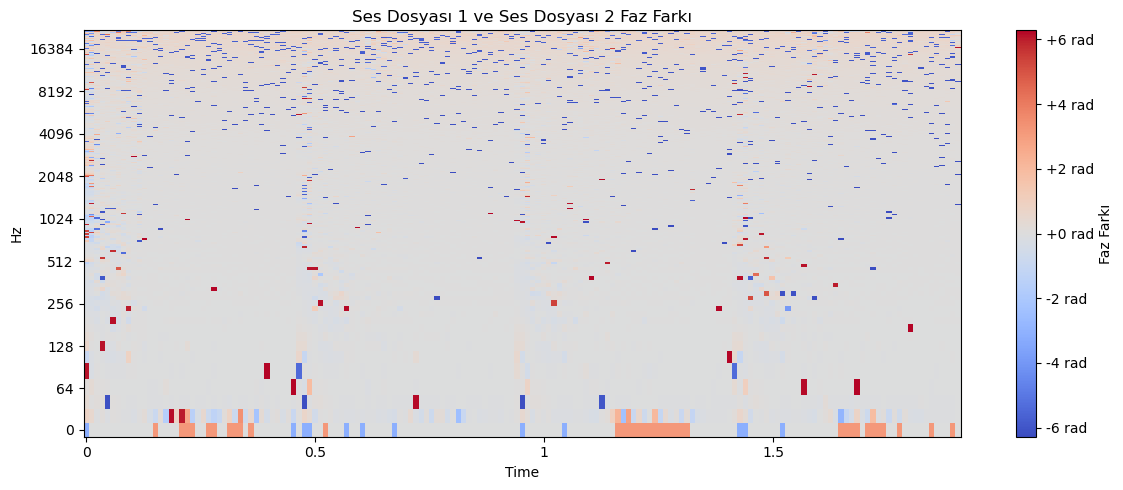

In [1]:
import matplotlib.pyplot as plt # Grafik çizimleri için kullanılan kütüphane
import numpy as np # Sayısal hesaplamalar
import librosa # Ses yükleme ve analizi
import librosa.display # Ses dalga formu görselleştirme

# Ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav" # İlk karşılaştırılacak ses dosyasının yolu
file_2 = "/Users/nazimerensahin/Desktop/2.wav" # İkinci karşılaştırılacak ses dosyasının yolu

# Ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1" # Grafik etiketi için ilk dosya ismi
label_2 = "Ses Dosyası 2" # Grafik etiketi için ikinci dosya ismi

# Ses dosyalarını yükleme
wave_1, sr_1 = librosa.load(file_1, sr=None) # Birinci ses dosyasını yükleme
wave_2, sr_2 = librosa.load(file_2, sr=None) # İkinci ses dosyasını yükleme

# Faz farkını hesaplayıp görselleştirme
def plot_phase_difference(y_ref, sr_ref, y_comp, sr_comp, title):
    S_ref = librosa.stft(y_ref) # Referans sesin STFT işlemi (zamana bağlı frekans bileşenleri)
    S_comp = librosa.stft(y_comp) # Karşılaştırılacak sesin STFT işlemi (zamana bağlı frekans bileşenleri)

    phase_ref = np.angle(S_ref) # Referans sinyalin faz bilgisi (radyan cinsinden)
    phase_comp = np.angle(S_comp) # Karşılaştırılan sinyalin faz bilgisi (radyan cinsinden)
    phase_diff = phase_ref - phase_comp # İki sinyal arasındaki faz farkı hesaplama

    # Faz farkını görselleştirme
    plt.figure(figsize=(12, 5)) # Grafik boyutunu ayarlama
    img = librosa.display.specshow(
        phase_diff, sr=sr_ref, x_axis="time", y_axis="log", cmap="coolwarm"  # Faz farkını renkli olarak gösterme
    )
    plt.title(title) # Grafiğin başlığı
    plt.colorbar(img, format="%+2.0f rad", label="Faz Farkı") # Renk skalası (radyan cinsinden) ve etiket
    plt.tight_layout() # Grafik elemanlarının sıkı yerleşimini sağlama
    plt.show() # Grafiği ekranda gösterirme

# Fonksiyonu çağırarak karşılaştırmayı gerçekleştirme
plot_phase_difference(wave_1, sr_1, wave_2, sr_2, f"{label_1} ve {label_2} Faz Farkı")